# HW2 Solute Transport


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import erfc


## Q2.3 – Analytical flux-averaged BTCs at the outlet

At the outlet, x=L contant V and L, D = VL/Pe.


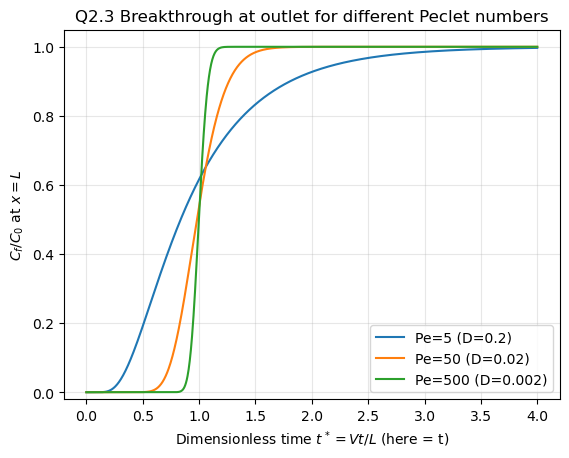

Saved: Q2_3_breakthrough_Pe.png


In [2]:
def cf_step_flux(x, t, V, D):
    """Flux-averaged step-response at x for semi-infinite ADE."""
    t = np.asarray(t, dtype=float)
    out = np.zeros_like(t)
    mask = t > 0
    tm = t[mask]
    arg1 = (x - V*tm) / (2*np.sqrt(D*tm))
    arg2 = (x + V*tm) / (2*np.sqrt(D*tm))
    out[mask] = 0.5*(erfc(arg1) + np.exp(V*x/D)*erfc(arg2))
    return out

# Plot Q2.3
L = 1.0
V = 1.0
t = np.linspace(0, 4.0, 1200)  # dimensionless time t* = Vt/L (here equals t)
pes = [5, 50, 500]

plt.figure()
for pe in pes:
    D = V*L/pe
    y = cf_step_flux(L, t, V, D)
    plt.plot(t, y, label=f"Pe={pe} (D={D:.4g})")

plt.xlabel(r"Dimensionless time $t^* = Vt/L$ (here = t)")
plt.ylabel(r"$C_f/C_0$ at $x=L$")
plt.title("Q2.3 Breakthrough at outlet for different Peclet numbers")
plt.ylim(-0.02, 1.05)
plt.legend()
plt.grid(True, alpha=0.3)

out_png = "Q2_3_breakthrough_Pe.png"
plt.savefig(out_png, dpi=200, bbox_inches="tight")
plt.show()

print(f"Saved: {out_png}")


## Finite-domain numerical solver Q6

In [3]:
def build_M_and_source(N, L, V, D, bc_type="flux"):
    """
    Build tridiagonal operator M for dC/dt = M C + sCin*Cin(t)
    using finite-volume upwind advection and central diffusion.
    """
    dx = L / (N-1)
    aL = np.zeros(N)  # lower diag
    aD = np.zeros(N)  # main diag
    aU = np.zeros(N)  # upper diag
    sCin = np.zeros(N)

    # inlet cell i=0
    if bc_type == "flux":
        aD[0] = -(V/dx) - (D/dx**2)
        aU[0] = (D/dx**2)
        sCin[0] = (V/dx)
    elif bc_type == "dirichlet":
        aD[0] = -(V/dx) - (2*D/dx**2)
        aU[0] = (D/dx**2)
        sCin[0] = (V/dx) + (D/dx**2)
    else:
        raise ValueError("bc_type must be 'flux' or 'dirichlet'")

    # interior
    for i in range(1, N-1):
        aL[i] = (D/dx**2) + (V/dx)
        aD[i] = -(2*D/dx**2) - (V/dx)
        aU[i] = (D/dx**2)

    # outlet i=N-1 (Neumann for diffusion; advective outflow)
    i = N-1
    aL[i] = (V/dx) + (D/dx**2)
    aD[i] = -(V/dx) - (D/dx**2)
    aU[i] = 0.0

    return aL, aD, aU, sCin, dx


def thomas_solve(aL, aD, aU, b):
    """Solve tri-diagonal system with Thomas algorithm."""
    n = len(aD)
    c = aU.copy()
    d = aD.copy()
    bb = b.copy().astype(float)

    for i in range(1, n):
        w = aL[i] / d[i-1]
        d[i] -= w * c[i-1]
        bb[i] -= w * bb[i-1]

    x = np.zeros(n)
    x[-1] = bb[-1] / d[-1]
    for i in range(n-2, -1, -1):
        x[i] = (bb[i] - c[i]*x[i+1]) / d[i]
    return x


def simulate_transport(
    L=1.0, N=201, V=1.0, D=0.02,
    t_end=3.0, dt=0.002,
    bc_type="flux",
    Cin_func=None,
    model="none",
    sorp_params=None,
    C_init=None
):
    """
    1D ADE with optional sorption.
    model: 'none', 'linear', 'freundlich', 'langmuir', 'two_site'
    sorp_params uses:
      theta (porosity), rho_b (kg/L), Kd (L/kg), Kf, Nexp, Smax, b, Fs, alpha
    """
    if Cin_func is None:
        Cin_func = lambda t: 0.0
    if sorp_params is None:
        sorp_params = {}

    aL, aD, aU, sCin, dx = build_M_and_source(N, L, V, D, bc_type=bc_type)
    x = np.linspace(0, L, N)

    nsteps = int(np.ceil(t_end/dt))
    t = np.linspace(0, nsteps*dt, nsteps+1)
    C = np.zeros(N) if C_init is None else np.array(C_init, dtype=float).copy()

    if model == "two_site":
        Csk = np.zeros(N)

    Cout = np.zeros(nsteps+1)
    Cout[0] = C[-1]

    theta = sorp_params.get("theta", 0.35)
    rho_b = sorp_params.get("rho_b", 1.65)

    def R_linear():
        Kd = sorp_params.get("Kd", 0.0)
        return 1.0 + (rho_b * Kd)/theta

    def R_freundlich(Cval):
        Kf = sorp_params.get("Kf", 0.0)
        Nexp = sorp_params.get("Nexp", 1.0)
        if Kf == 0.0:
            return np.ones_like(Cval)
        # For N<1, dCs/dC ~ C^(N-1) is singular at C=0; use a small threshold.
        Ceff = np.maximum(Cval, 1e-6)
        dCs_dC = Nexp * Kf * (Ceff**(Nexp - 1.0))
        return 1.0 + (rho_b/theta)*dCs_dC

    def R_langmuir(Cval):
        Smax = sorp_params.get("Smax", 1.0)
        b = sorp_params.get("b", 1.0)
        Ceff = np.maximum(Cval, 0.0)
        dCs_dC = (Smax * b) / (1.0 + b*Ceff)**2
        return 1.0 + (rho_b/theta)*dCs_dC

    for n in range(1, nsteps+1):
        tn1 = t[n]
        Cin = float(Cin_func(tn1))
        source = sCin * Cin

        if model == "none":
            R = 1.0
            diag = (R/dt) - aD
            rhs = (R/dt)*C + source
            C = thomas_solve(-aL, diag, -aU, rhs)

        elif model == "linear":
            R = R_linear()
            diag = (R/dt) - aD
            rhs = (R/dt)*C + source
            C = thomas_solve(-aL, diag, -aU, rhs)

        elif model == "freundlich":
            Cguess = C.copy()
            for _ in range(5):
                Rvec = R_freundlich(Cguess)
                diag = (Rvec/dt) - aD
                rhs = (Rvec/dt)*C + source
                Cnew = thomas_solve(-aL, diag, -aU, rhs)
                Cguess = 0.5*Cguess + 0.5*Cnew
            C = Cguess

        elif model == "langmuir":
            Cguess = C.copy()
            for _ in range(5):
                Rvec = R_langmuir(Cguess)
                diag = (Rvec/dt) - aD
                rhs = (Rvec/dt)*C + source
                Cnew = thomas_solve(-aL, diag, -aU, rhs)
                Cguess = 0.5*Cguess + 0.5*Cnew
            C = Cguess

        elif model == "two_site":
            # Two-site kinetic sorption (common in transport texts):
            # fraction Fs in instantaneous equilibrium, rest kinetic with rate alpha
            Kd = sorp_params.get("Kd", 0.8)
            Fs = sorp_params.get("Fs", 0.5)
            alpha = sorp_params.get("alpha", 0.05)  # 1/time
            R_eq = 1.0 + (rho_b/theta)*Fs*Kd
            kin_coef = (rho_b/theta) * alpha * (1.0 - Fs) * Kd / (1.0 + alpha*dt)
            acoef = (R_eq/dt) + kin_coef

            diag = acoef - aD
            rhs = (R_eq/dt)*C + (rho_b/theta)*alpha*Csk/(1.0 + alpha*dt) + source
            C_new = thomas_solve(-aL, diag, -aU, rhs)

            Csk = (Csk + dt*alpha*(1.0 - Fs)*Kd*C_new) / (1.0 + alpha*dt)
            C = C_new

        else:
            raise ValueError("Unknown model")

        C = np.clip(C, 0.0, 1.2)
        Cout[n] = C[-1]

    return t, x, C, Cout


## Q6 Plots

pulse input at the inlet


parameters:
- L=1, V=1, D=0.02, Pe≈50, N=301, t_0=0.2


In [4]:
# Pulse input
t0 = 0.2
pulse = lambda tt: 1.0 if (0.0 <= tt <= t0) else 0.0

# Common numerical params
L = 1.0
V = 1.0
D = 0.02
N = 301
dt = 0.001


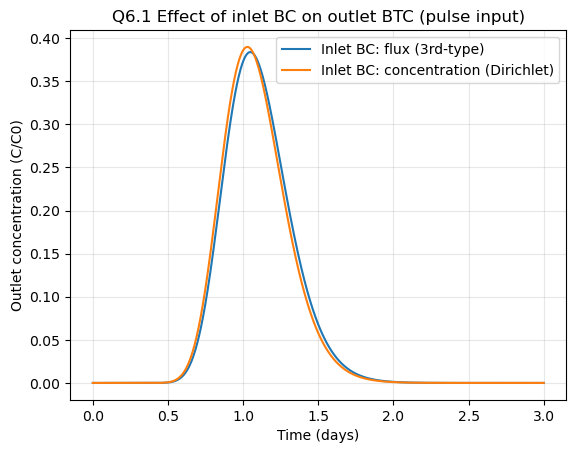

Saved: Q6_1_bc_type.png


In [5]:
# Q6.1 – inlet boundary condition type comparison
params = dict(L=L, N=N, V=V, D=D, t_end=3.0, dt=dt, Cin_func=pulse)

t_f, x, _, Cout_flux = simulate_transport(bc_type="flux", model="none", sorp_params={}, **params)
t_d, x, _, Cout_dir  = simulate_transport(bc_type="dirichlet", model="none", sorp_params={}, **params)

plt.figure()
plt.plot(t_f, Cout_flux, label="Inlet BC: flux (3rd-type)")
plt.plot(t_d, Cout_dir,  label="Inlet BC: concentration (Dirichlet)")
plt.xlabel("Time (days)")
plt.ylabel("Outlet concentration (C/C0)")
plt.title("Q6.1 Effect of inlet BC on outlet BTC (pulse input)")
plt.legend()
plt.grid(True, alpha=0.3)

out_png = "Q6_1_bc_type.png"
plt.savefig(out_png, dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved: {out_png}")


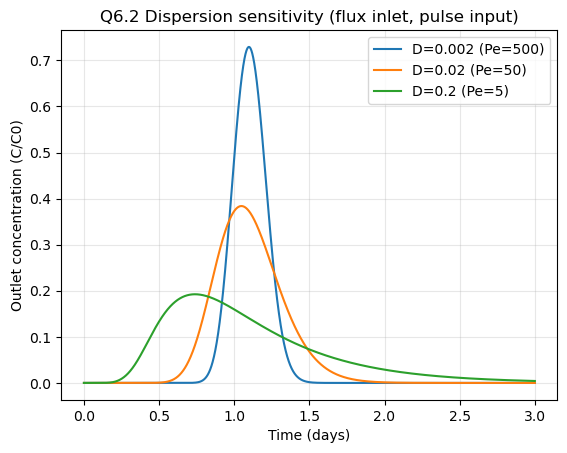

Saved: Q6_2_dispersion.png


In [6]:
# Q6.2 – dispersion sensitivity
Ds = [0.002, 0.02, 0.2]  # Pe ~ 500, 50, 5 (for L=V=1)

plt.figure()
for Dtest in Ds:
    t_s, x, _, Cout = simulate_transport(L=L, N=N, V=V, D=Dtest, t_end=3.0, dt=dt,
                                         bc_type="flux", Cin_func=pulse,
                                         model="none", sorp_params={})
    plt.plot(t_s, Cout, label=f"D={Dtest:g} (Pe={V*L/Dtest:.0f})")

plt.xlabel("Time (days)")
plt.ylabel("Outlet concentration (C/C0)")
plt.title("Q6.2 Dispersion sensitivity (flux inlet, pulse input)")
plt.legend()
plt.grid(True, alpha=0.3)

out_png = "Q6_2_dispersion.png"
plt.savefig(out_png, dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved: {out_png}")


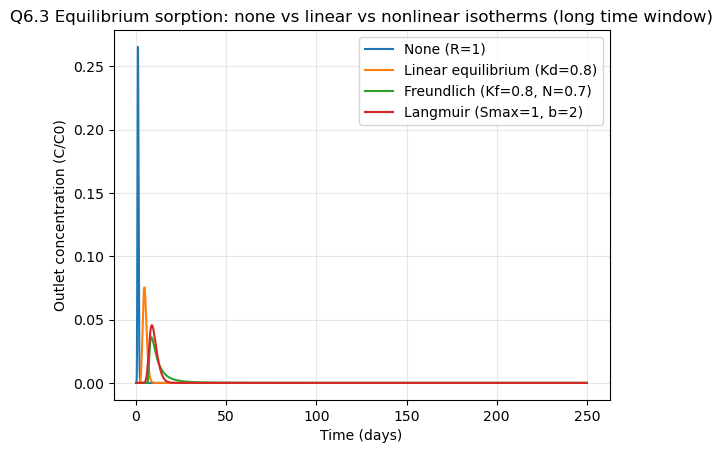

Saved: Q6_3_equilibrium_sorption.png


In [7]:
# Q6.3 – equilibrium sorption comparison (longer time window to show nonlinear effects)
sorp_common = {"theta": 0.35, "rho_b": 1.65}

t_end_long = 250.0
dt_long = 0.05

plt.figure()

t_s, x, _, Cout_none = simulate_transport(L=L, N=N, V=V, D=D, t_end=t_end_long, dt=dt_long,
                                         bc_type="flux", Cin_func=pulse,
                                         model="none", sorp_params=sorp_common)
plt.plot(t_s, Cout_none, label="None (R=1)")

t_s, x, _, Cout_lin = simulate_transport(L=L, N=N, V=V, D=D, t_end=t_end_long, dt=dt_long,
                                        bc_type="flux", Cin_func=pulse,
                                        model="linear", sorp_params={**sorp_common, "Kd": 0.8})
plt.plot(t_s, Cout_lin, label="Linear equilibrium (Kd=0.8)")

t_s, x, _, Cout_fr = simulate_transport(L=L, N=N, V=V, D=D, t_end=t_end_long, dt=dt_long,
                                       bc_type="flux", Cin_func=pulse,
                                       model="freundlich", sorp_params={**sorp_common, "Kf": 0.8, "Nexp": 0.7})
plt.plot(t_s, Cout_fr, label="Freundlich (Kf=0.8, N=0.7)")

t_s, x, _, Cout_la = simulate_transport(L=L, N=N, V=V, D=D, t_end=t_end_long, dt=dt_long,
                                       bc_type="flux", Cin_func=pulse,
                                       model="langmuir", sorp_params={**sorp_common, "Smax": 1.0, "b": 2.0})
plt.plot(t_s, Cout_la, label="Langmuir (Smax=1, b=2)")

plt.xlabel("Time (days)")
plt.ylabel("Outlet concentration (C/C0)")
plt.title("Q6.3 Equilibrium sorption: none vs linear vs nonlinear isotherms (long time window)")
plt.legend()
plt.grid(True, alpha=0.3)

out_png = "Q6_3_equilibrium_sorption.png"
plt.savefig(out_png, dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved: {out_png}")


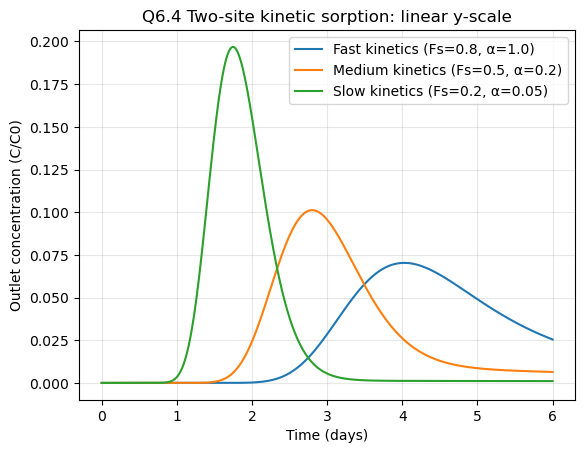

Saved: Q6_4_kinetic_linear.png


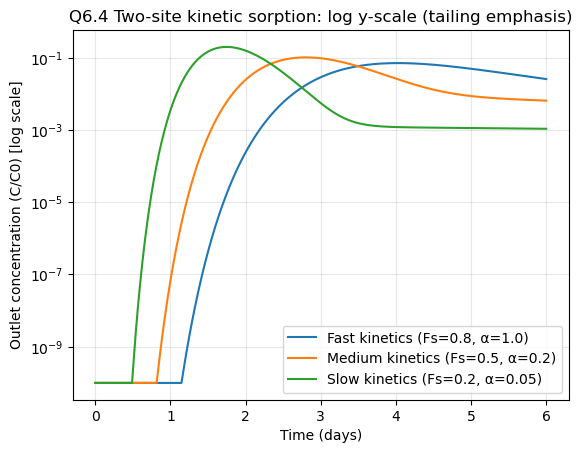

Saved: Q6_4_kinetic_log.png


In [8]:
# Q6.4 – two-site kinetic sorption tailing (linear + log y-scale)
sorp_common = {"theta": 0.35, "rho_b": 1.65}

configs = [
    ("Fast kinetics (Fs=0.8, α=1.0)",  {"Kd": 0.8, "Fs": 0.8, "alpha": 1.0}),
    ("Medium kinetics (Fs=0.5, α=0.2)", {"Kd": 0.8, "Fs": 0.5, "alpha": 0.2}),
    ("Slow kinetics (Fs=0.2, α=0.05)",  {"Kd": 0.8, "Fs": 0.2, "alpha": 0.05}),
]

t_end_kin = 6.0

# Linear y
plt.figure()
series = []
for label, sp in configs:
    t_s, x, _, Cout = simulate_transport(L=L, N=N, V=V, D=D, t_end=t_end_kin, dt=dt,
                                         bc_type="flux", Cin_func=pulse,
                                         model="two_site", sorp_params={**sorp_common, **sp})
    series.append((label, t_s, Cout))
    plt.plot(t_s, Cout, label=label)

plt.xlabel("Time (days)")
plt.ylabel("Outlet concentration (C/C0)")
plt.title("Q6.4 Two-site kinetic sorption: linear y-scale")
plt.legend()
plt.grid(True, alpha=0.3)

out_png = "Q6_4_kinetic_linear.png"
plt.savefig(out_png, dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved: {out_png}")

# Log y
plt.figure()
for label, t_s, Cout in series:
    plt.semilogy(t_s, np.maximum(Cout, 1e-10), label=label)

plt.xlabel("Time (days)")
plt.ylabel("Outlet concentration (C/C0) [log scale]")
plt.title("Q6.4 Two-site kinetic sorption: log y-scale (tailing emphasis)")
plt.legend()
plt.grid(True, alpha=0.3, which="both")

out_png = "Q6_4_kinetic_log.png"
plt.savefig(out_png, dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved: {out_png}")
